<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-PedroArthurs/blob/main/Atividade_wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Biblioteca**

In [ ]:
pip install ucimlrepo

# **Data**

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

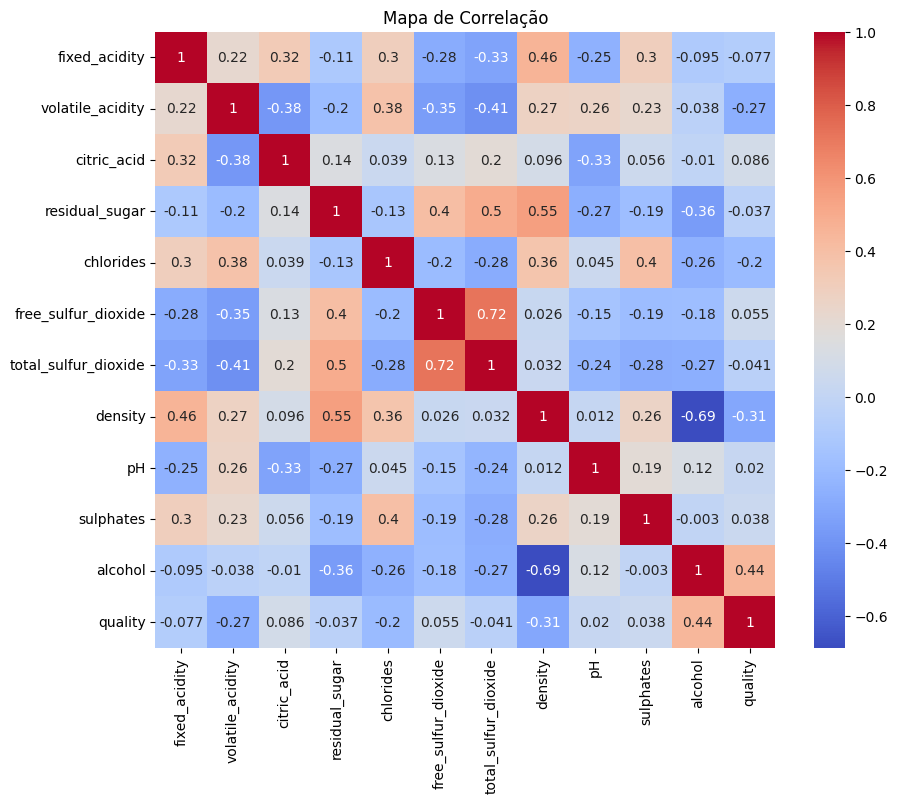

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# carregar dataset
wine_quality = fetch_ucirepo(id=186)

# features e target
X = wine_quality.data.features
y = wine_quality.data.targets

# juntar tudo em um dataframe
df = pd.concat([X, y], axis=1)

# visualizar primeiras linhas
print(df.head())

# estatísticas gerais
print(df.describe())

# correlação
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Mapa de Correlação")
plt.show()

# **Descoberta 1:**

**Afirmação:** Vinhos com maior acidez volátil tendem a receber notas menores.

**Código**

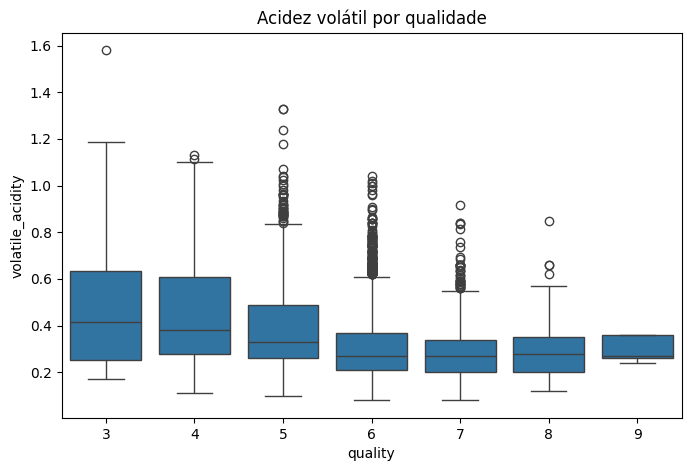

                  volatile_acidity   quality
volatile_acidity          1.000000 -0.265699
quality                  -0.265699  1.000000


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='volatile_acidity', data=df)
plt.title("Acidez volátil por qualidade")
plt.show()

print(df[['volatile_acidity', 'quality']].corr())

**Print da Evidência:** 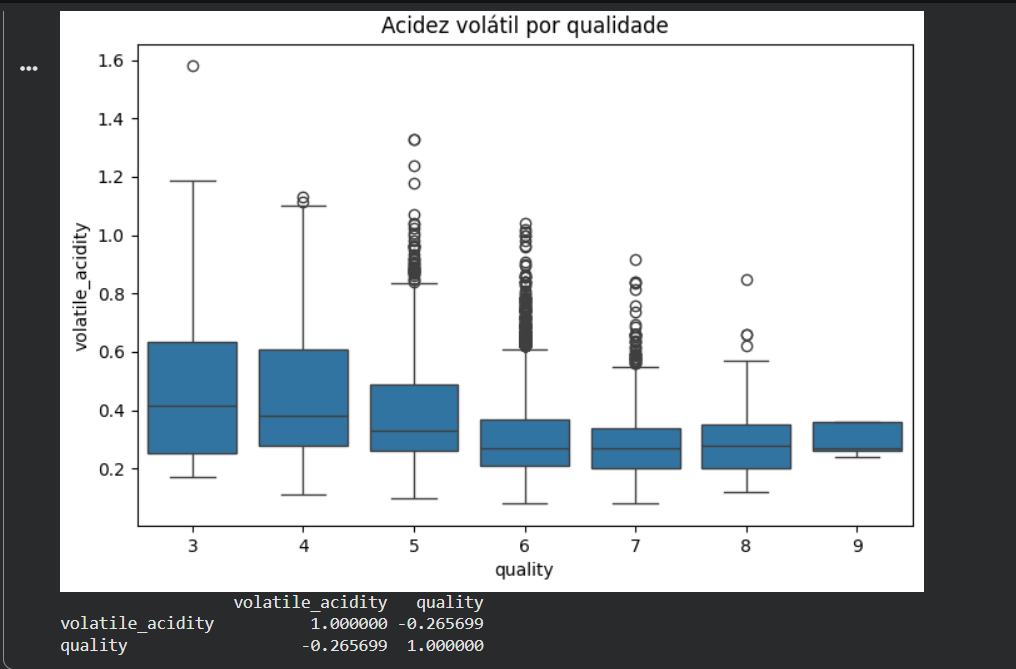

**Interpretação:** O boxplot mostra que vinhos com notas maiores geralmente possuem menor acidez volátil.
A correlação negativa confirma essa tendência, indicando que o aumento da acidez volátil pode reduzir a qualidade percebida do vinho.

# **Descoberta 2:**

**Afirmação:** Vinhos com maior densidade tendem a ter qualidade menor.

**Código**

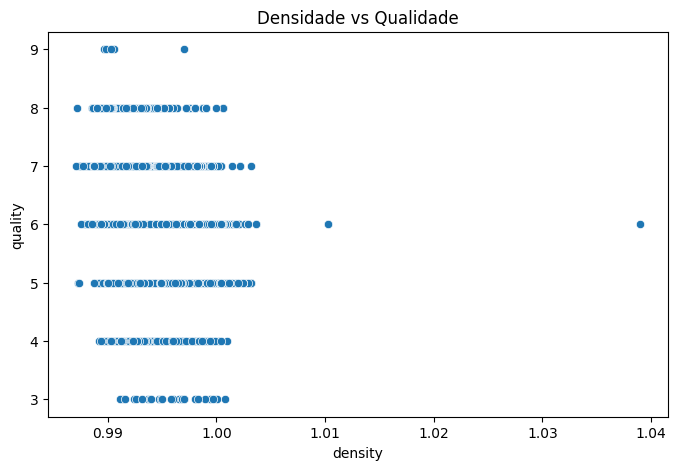

          density   quality
density  1.000000 -0.305858
quality -0.305858  1.000000


In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='density', y='quality', data=df)
plt.title("Densidade vs Qualidade")
plt.show()

print(df[['density', 'quality']].corr())

**Print da Evidência:** 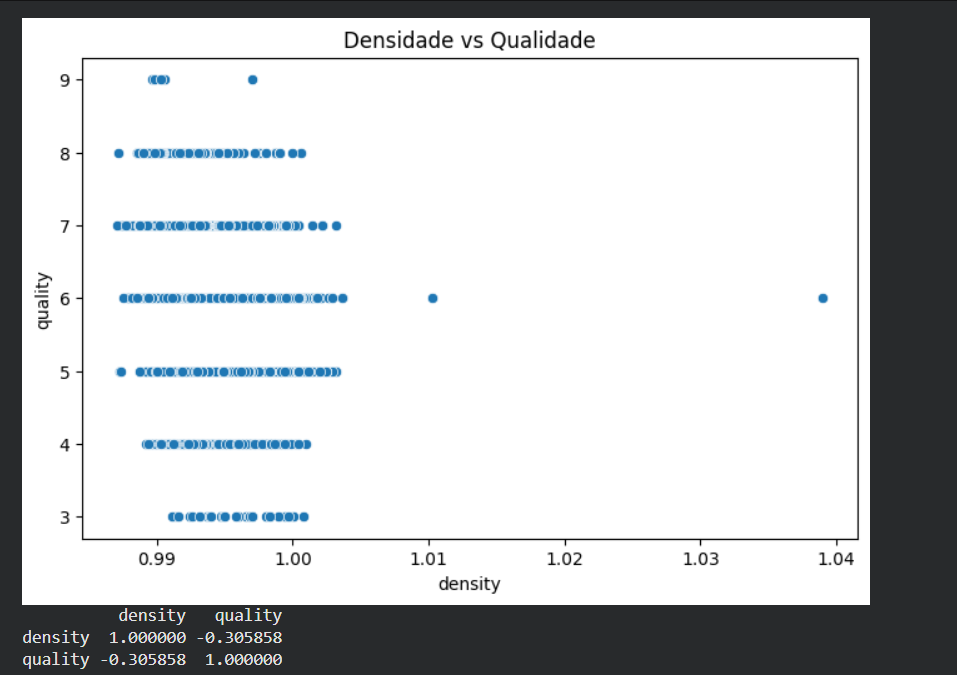

**Interpretação:** O gráfico mostra uma tendência de queda na qualidade conforme a densidade aumenta.
A correlação negativa sugere que vinhos mais densos costumam receber avaliações inferiores.

# **Descoberta 3**

**Afirmação:** Vinhos com maiores níveis de sulfatos tendem a possuir qualidade superior.

**Código**

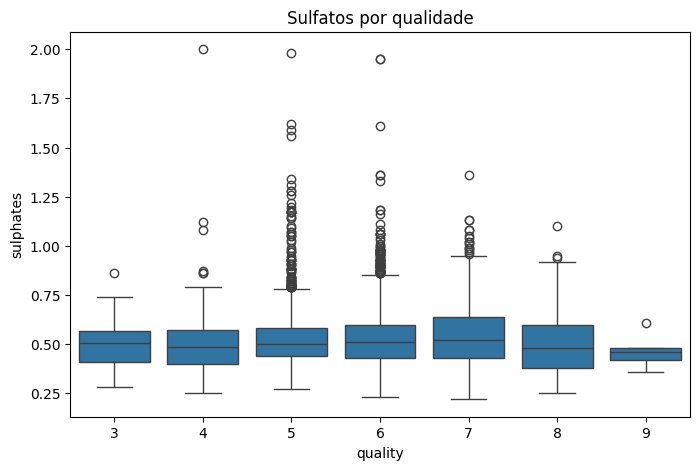

           sulphates   quality
sulphates   1.000000  0.038485
quality     0.038485  1.000000


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='sulphates', data=df)
plt.title("Sulfatos por qualidade")
plt.show()

print(df[['sulphates', 'quality']].corr())

**Print da Evidência:** 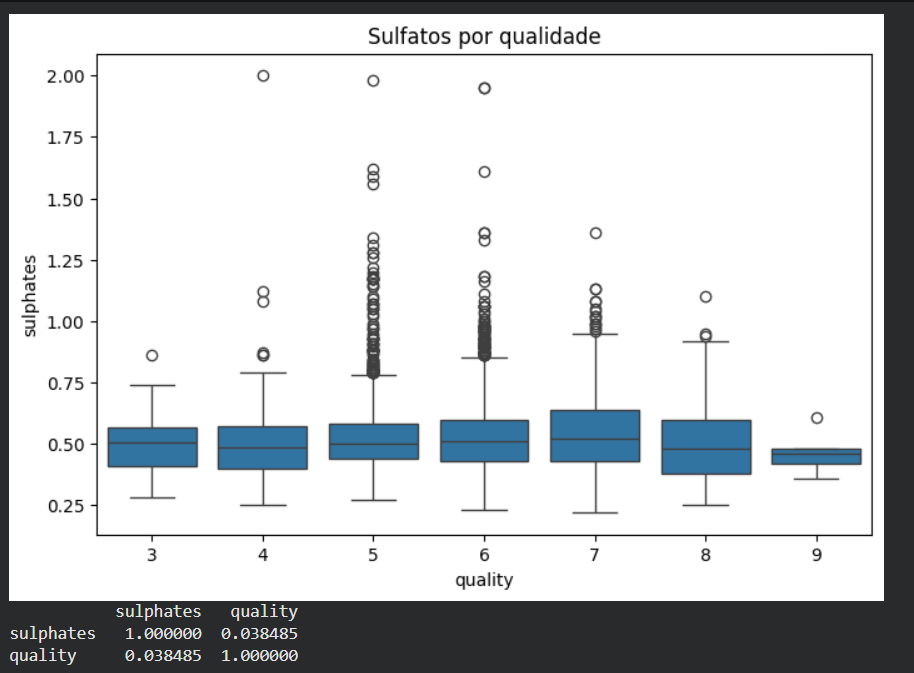

**Interpretação:** Os vinhos com melhores notas apresentam concentrações medianas maiores de sulfatos.
A correlação positiva indica que níveis moderadamente maiores de sulfatos podem estar associados a uma melhor avaliação sensorial.